# Lecture 15: Complex Manifolds

**Source span.** Printed pages 81-87; physical PDF pages 95-101 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this lecture before revising the notebook.

**Lecture goal.** Move from almost complex linear algebra to genuine complex manifolds. A complex manifold is built from charts whose transition maps are biholomorphic. Those holomorphic transition maps force the local definitions of `J`, `(1,0)/(0,1)` tangent and cotangent types, `partial`, `dbar`, and Dolbeault cohomology to glue correctly.

The chapter's core distinction is pointwise versus integrable structure. Lecture 14 already showed the algebraic type splitting for an almost complex structure. Here the existence of holomorphic coordinates gives the stronger identity `d=partial+dbar` on forms, `dbar^2=0`, and the Newlander-Nirenberg equivalence between integrability, vanishing Nijenhuis tensor, and the Dolbeault complex.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-15"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-15


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Complex atlas | chart graph with biholomorphic transition maps | transition maps satisfy Cauchy-Riemann equations and have holomorphic inverse |
| Canonical almost complex structure | matrix `J` with `J(partial_x)=partial_y` | Cauchy-Riemann equations make `J` independent of chart |
| Complexified tangent split | projectors to `T^{1,0}` and `T^{0,1}` | `partial_z` is `+i` eigenvector, `partial_zbar` is `-i` eigenvector |
| Cotangent type split | `dz=dx+i dy`, `dzbar=dx-i dy` | forms decompose into `(l,m)` types using wedge products |
| Differential decomposition | `d=partial+dbar` | holomorphic coordinates make `db=sum b_z dz + b_zbar dzbar` |
| Dolbeault cohomology | `dbar` complex | requires `dbar^2=0`, hence integrability |
| Newlander-Nirenberg | equivalence ledger | complex charts, integrable `J`, vanishing Nijenhuis tensor, `d=partial+dbar`, and `dbar^2=0` are tied together |
| Complex projective space | homogeneous coordinates and affine charts `U_i` | transition maps such as `z -> 1/z` are holomorphic away from poles |

## Library Routing

This lecture is algebraic and chart-based, so `sympy` checks Cauchy-Riemann equations, projectors, Wirtinger derivatives, and CP1 transitions exactly. `matplotlib` draws atlas overlaps, type lattices, and CP1 chart geometry. `networkx` records the Newlander-Nirenberg equivalence ledger. `numpy` supplies small matrix residuals for the canonical `J` checks.

## Visual Storyboard

1. **Holomorphic atlas and canonical `J`.** The overlap diagram shows how Cauchy-Riemann equations make the local `J` definitions agree.
2. **Type decomposition lattice.** `T^{1,0}`, `T^{0,1}`, `dz`, `dzbar`, and `(l,m)` forms are organized as a bigraded grid.
3. **CP1 atlas transition.** The two affine charts on complex projective space are represented by the transition `w=1/z`, with a pole removed from the overlap.
4. **Dolbeault integrability ledger.** A graph records `d=partial+dbar`, `dbar^2=0`, and Newlander-Nirenberg dependencies.

In [2]:
# Visual 1: complex atlas transition and canonical J compatibility.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.9))
ax = axes[0]
ax.set_title("Complex charts require biholomorphic transitions")
centers = [(0.0,0.0),(1.8,0.15)]
for c, color, label in zip(centers, ["#8ecae6", "#90be6d"], ["U_alpha", "U_beta"]):
    circ = plt.Circle(c, 1.15, color=color, alpha=0.35, ec="#1f2937")
    ax.add_patch(circ)
    ax.text(c[0], c[1]+0.9, label, ha="center", weight="bold")
ax.annotate("psi = phi_beta o phi_alpha^{-1}\nholomorphic on overlap", xy=(0.9,0.1), xytext=(0.9,-1.35), ha="center", arrowprops={"arrowstyle":"->"}, bbox={"boxstyle":"round,pad=0.3", "fc":"#f4f7fb", "ec":"#8d99ae"})
ax.set_xlim(-1.5,3.3); ax.set_ylim(-1.7,1.6); ax.set_aspect("equal"); ax.axis("off")

ax = axes[1]
ax.set_title("Cauchy-Riemann equations preserve J")
A = np.array([[1.2, -0.45],[0.45, 1.2]])
J = np.array([[0,-1],[1,0]])
for vec, color, name in [(np.array([1,0]), "#1d3557", "partial_x"), (np.array([0,1]), "#e76f51", "partial_y")]:
    ax.arrow(0,0,vec[0],vec[1], head_width=0.06, color=color, length_includes_head=True)
    image=A@vec
    ax.arrow(1.7,0,image[0]*0.55,image[1]*0.55, head_width=0.06, color=color, length_includes_head=True)
    ax.text(vec[0]*1.12, vec[1]*1.12, name, color=color)
ax.text(0.55,-0.45,"Dpsi", ha="center")
ax.text(1.75,1.1,"Dpsi J = J Dpsi", ha="center", bbox={"boxstyle":"round,pad=0.3", "fc":"#e8f3ee", "ec":"#4d908e"})
ax.set_xlim(-0.4,3.0); ax.set_ylim(-1.1,1.55); ax.set_aspect("equal"); ax.axis("off")
atlas_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "complex-atlas-canonical-J-compatibility.png")
plt.close(fig)
print(atlas_path.relative_to(BOOK_ROOT))
assert np.allclose(A@J, J@A)

artifacts\lecture-15\figures\complex-atlas-canonical-J-compatibility.png


In [3]:
# Visual 2: tangent/cotangent type decomposition and form lattice.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax=axes[0]
ax.set_title("Complexified tangent/cotangent splitting")
items=[("partial_z", "+i eigenspace", 0.25,0.72,"#8ecae6"),("partial_zbar", "-i eigenspace",0.25,0.32,"#f9c74f"),("dz", "(1,0)-form",0.72,0.72,"#90be6d"),("dzbar","(0,1)-form",0.72,0.32,"#e76f51")]
for name,desc,x0,y0,color in items:
    ax.text(x0,y0,name+"\n"+desc,ha="center",va="center",bbox={"boxstyle":"round,pad=0.35","fc":color,"alpha":0.75,"ec":"#1f2937"})
ax.annotate("dual type",xy=(0.62,0.72),xytext=(0.36,0.72),arrowprops={"arrowstyle":"->"})
ax.annotate("dual type",xy=(0.62,0.32),xytext=(0.36,0.32),arrowprops={"arrowstyle":"->"})
ax.axis("off")

ax=axes[1]
ax.set_title("Forms of type (l,m)")
for l in range(4):
    for m in range(4-l):
        ax.scatter([l],[m],s=520,color="#f4f7fb",edgecolor="#1f2937")
        ax.text(l,m,f"({l},{m})",ha="center",va="center")
for l in range(3):
    for m in range(3-l):
        ax.annotate("",xy=(l+0.75,m),xytext=(l+0.25,m),arrowprops={"arrowstyle":"->","color":"#1d3557"})
        ax.annotate("",xy=(l,m+0.75),xytext=(l,m+0.25),arrowprops={"arrowstyle":"->","color":"#e76f51"})
ax.text(2.0,-0.35,"partial raises l",color="#1d3557",ha="center")
ax.text(-0.45,2.0,"dbar raises m",color="#e76f51",rotation=90,va="center")
ax.set_xlim(-0.7,3.4); ax.set_ylim(-0.6,3.4); ax.set_aspect("equal"); ax.axis("off")
type_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "complex-type-decomposition-lattice.png")
plt.close(fig)
print(type_path.relative_to(BOOK_ROOT))
assert type_path.exists()

artifacts\lecture-15\figures\complex-type-decomposition-lattice.png


In [4]:
# Visual 3: CP1 two-chart atlas and the transition w=1/z.
fig, axes = plt.subplots(1,2,figsize=(12,4.8))
for ax,title,missing in [(axes[0],"U0 chart: z=z1/z0", "infinity"),(axes[1],"U1 chart: w=z0/z1", "zero")]:
    ax.set_title(title)
    ax.axhline(0,color="#d0d7de"); ax.axvline(0,color="#d0d7de")
    circle=plt.Circle((0,0),1.0,fill=False,color="#1d3557",lw=2)
    ax.add_patch(circle)
    ax.scatter([0],[0],color="#e76f51" if missing=="zero" else "#90be6d",s=80,zorder=3)
    ax.text(0,-1.35,f"missing point: {missing}",ha="center")
    ax.set_xlim(-1.6,1.6); ax.set_ylim(-1.6,1.6); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
axes[0].annotate("transition on overlap\nw=1/z", xy=(1.42,0.0), xytext=(2.2,0.0), xycoords="data", textcoords="data", arrowprops={"arrowstyle":"->"}, ha="center")
cp1_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "cp1-two-chart-holomorphic-transition.png")
plt.close(fig)
print(cp1_path.relative_to(BOOK_ROOT))
assert cp1_path.exists()

artifacts\lecture-15\figures\cp1-two-chart-holomorphic-transition.png


In [5]:
# Visual 4: Newlander-Nirenberg and Dolbeault dependency graph.
G=nx.DiGraph()
edges=[("holomorphic atlas","canonical J"),("holomorphic atlas","holomorphic coordinates"),("Cauchy-Riemann transitions","canonical J"),("canonical J","type splitting"),("holomorphic coordinates","d=partial+dbar"),("d=partial+dbar","dbar^2=0"),("dbar^2=0","Dolbeault cohomology"),("Nijenhuis tensor N","integrability gate"),("N=0","complex charts"),("complex charts","holomorphic atlas"),("Newlander-Nirenberg","N=0"),("Newlander-Nirenberg","complex charts")]
G.add_edges_from(edges)
pos={"holomorphic atlas":(0,1),"Cauchy-Riemann transitions":(0,0),"canonical J":(2,0.5),"type splitting":(4,0.5),"holomorphic coordinates":(4,-0.7),"d=partial+dbar":(6,-0.7),"dbar^2=0":(8,-0.7),"Dolbeault cohomology":(10,-0.7),"Nijenhuis tensor N":(2,-1.8),"integrability gate":(4,-1.8),"N=0":(6,-1.8),"complex charts":(8,-1.8),"Newlander-Nirenberg":(6,-2.75)}
fig,ax=plt.subplots(figsize=(12,5.2))
colors=["#90be6d" if "Dolbeault" in n or "dbar" in n else "#8ecae6" if "J" in n or "type" in n else "#f9c74f" for n in G.nodes]
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle="-|>",edge_color="#495057")
nx.draw_networkx_nodes(G,pos,ax=ax,node_color=colors,node_size=1650,edgecolors="#1f2937")
nx.draw_networkx_labels(G,pos,ax=ax,font_size=8)
ax.set_axis_off(); ax.set_title("Complex manifolds: chart compatibility opens the Dolbeault complex")
ledger_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "dolbeault-newlander-nirenberg-ledger.png")
plt.close(fig)
print(ledger_path.relative_to(BOOK_ROOT))
assert nx.has_path(G,"holomorphic atlas","Dolbeault cohomology")

artifacts\lecture-15\figures\dolbeault-newlander-nirenberg-ledger.png


In [6]:
# Exact checks: CR equations, projectors, Wirtinger derivatives, CP1 transition.
x,y=sp.symbols("x y", real=True)
z=x+sp.I*y
# holomorphic square map u+iv=z^2
u=x**2-y**2
v=2*x*y
cr1=sp.simplify(sp.diff(u,x)-sp.diff(v,y))
cr2=sp.simplify(sp.diff(u,y)+sp.diff(v,x))
J=sp.Matrix([[0,-1],[1,0]])
A=sp.Matrix([[sp.diff(u,x), sp.diff(u,y)],[sp.diff(v,x), sp.diff(v,y)]])
commutator=A*J-J*A
I=sp.eye(2)
P10=(I-sp.I*J)/2
P01=(I+sp.I*J)/2
projector_checks={"P10_idempotent": sp.simplify((P10*P10-P10)[0,0])==0 and sp.simplify((P10*P10-P10)[1,1])==0,
                  "P01_idempotent": sp.simplify((P01*P01-P01)[0,0])==0 and sp.simplify((P01*P01-P01)[1,1])==0,
                  "sum_identity": P10+P01==I}
# Wirtinger checks for holomorphic z^3 and antiholomorphic zbar^2.
zbar=x-sp.I*y
def dzbar_derivative(expr): return sp.simplify(sp.Rational(1,2)*(sp.diff(expr,x)+sp.I*sp.diff(expr,y)))
def dz_derivative(expr): return sp.simplify(sp.Rational(1,2)*(sp.diff(expr,x)-sp.I*sp.diff(expr,y)))
holo_check=dzbar_derivative(z**3)
antiholo_check=dz_derivative(zbar**2)
# CP1 transition w=1/z is holomorphic off z=0: dbar(1/z)=0 symbolically.
transition_check=dzbar_derivative(1/z)
checks={"lecture":15,
        "cauchy_riemann":{"cr1":str(cr1),"cr2":str(cr2),"Dpsi_commutes_with_J": bool(commutator==sp.zeros(2))},
        "projectors": projector_checks,
        "wirtinger":{"dbar_z_cubed":str(holo_check),"partial_zbar_squared":str(antiholo_check)},
        "cp1_transition":{"dbar_one_over_z":str(sp.simplify(transition_check)),"holomorphic_on_overlap": bool(sp.simplify(transition_check)==0)},
        "dolbeault":{"dbar_holomorphic_zero": bool(holo_check==0),"partial_antiholomorphic_zero": bool(antiholo_check==0)}}
checks["passed"]=bool(cr1==0 and cr2==0 and commutator==sp.zeros(2) and all(projector_checks.values()) and holo_check==0 and antiholo_check==0 and transition_check==0)
check_path=save_json(checks, ARTIFACT_TOPIC, "checks", "complex-manifold-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert transition_check==0
assert all(projector_checks.values())

artifacts\lecture-15\checks\complex-manifold-residuals.json


## Reading The Visuals

The atlas diagram explains why a complex manifold has a canonical almost complex structure. In each holomorphic chart, `J` rotates `partial_x` to `partial_y`; on overlaps, the Cauchy-Riemann equations say the transition derivative commutes with this rotation, so the local definitions agree.

The type lattice is the bookkeeping system for forms. Tangent vectors split into `T^{1,0}` and `T^{0,1}`, cotangent vectors into `dz` and `dzbar`, and a form of type `(l,m)` has `l` holomorphic and `m` antiholomorphic factors. In holomorphic coordinates, exterior differentiation separates into `partial` and `dbar`, moving horizontally or vertically in the lattice.

The CP1 chart figure is the homework atlas in miniature. Homogeneous coordinates define affine charts by choosing a nonzero coordinate. On the overlap of the two standard charts, the transition is `w=1/z`, holomorphic away from the excluded point, so the charts define a complex structure.

The Newlander-Nirenberg graph keeps the integrability issue honest. The type projections exist for any almost complex structure, but Dolbeault cohomology needs `dbar^2=0`. Complex charts, vanishing Nijenhuis tensor, `d=partial+dbar`, and `dbar^2=0` are equivalent gates, not independent decorations.

In [7]:
source_span={"lecture":15,"label":"Lecture 15","title":"Complex Manifolds","printed_span":"81-87","physical_pdf_span":"95-101","source_checked":True,"source_role":"Used for terminology, theorem order, CPn homework themes, and theorem dependencies; prose and visuals here are original."}
visual_storyboard={"lecture":15,"title":"Complex Manifolds","source_span":source_span,"chapter_goal":"Make holomorphic atlases, canonical J, type decompositions, Dolbeault differentials, Newlander-Nirenberg, and CP1 charts inspectable.","library_routing":[{"library":"sympy","use":"Cauchy-Riemann, projector, Wirtinger, and CP1 transition checks"},{"library":"numpy","use":"small real matrix compatibility checks"},{"library":"matplotlib","use":"atlas, type lattice, and CP1 chart visuals"},{"library":"networkx","use":"Dolbeault/Newlander-Nirenberg dependency graph"}],"visual_sequence":[{"concept":"holomorphic atlas and canonical J","artifact":"artifacts/lecture-15/figures/complex-atlas-canonical-J-compatibility.png","inspection_target":"Cauchy-Riemann transitions commute with J"},{"concept":"complex type decomposition lattice","artifact":"artifacts/lecture-15/figures/complex-type-decomposition-lattice.png","inspection_target":"partial and dbar move through (l,m) form types"},{"concept":"CP1 two-chart atlas","artifact":"artifacts/lecture-15/figures/cp1-two-chart-holomorphic-transition.png","inspection_target":"w=1/z is holomorphic on chart overlap"},{"concept":"Dolbeault integrability ledger","artifact":"artifacts/lecture-15/figures/dolbeault-newlander-nirenberg-ledger.png","inspection_target":"Dolbeault cohomology depends on the integrability gate"}],"checks":"artifacts/lecture-15/checks/complex-manifold-residuals.json"}
final_sanity={"lecture":15,"passed":True,"source_span":"printed pages 81-87; physical PDF pages 95-101","artifacts":[item["artifact"] for item in visual_storyboard["visual_sequence"]]+["artifacts/lecture-15/checks/complex-manifold-residuals.json","artifacts/lecture-15/checks/source-span.json","artifacts/lecture-15/checks/visual-storyboard.json"],"definition_checks":{"cr_equations": checks["cauchy_riemann"]["Dpsi_commutes_with_J"],"projectors": all(checks["projectors"].values()),"holomorphic_dbar_zero": checks["dolbeault"]["dbar_holomorphic_zero"],"cp1_transition_holomorphic": checks["cp1_transition"]["holomorphic_on_overlap"]}}
save_json(source_span,ARTIFACT_TOPIC,"checks","source-span.json")
save_json(visual_storyboard,ARTIFACT_TOPIC,"checks","visual-storyboard.json")
save_json(final_sanity,ARTIFACT_TOPIC,"checks","final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path=BOOK_ROOT/relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size>0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count":len(final_sanity["artifacts"]),"passed":final_sanity["passed"]})

{'artifact_count': 7, 'passed': True}


holomorphic atlas and canonical J -> artifacts\lecture-15\figures\complex-atlas-canonical-J-compatibility.png


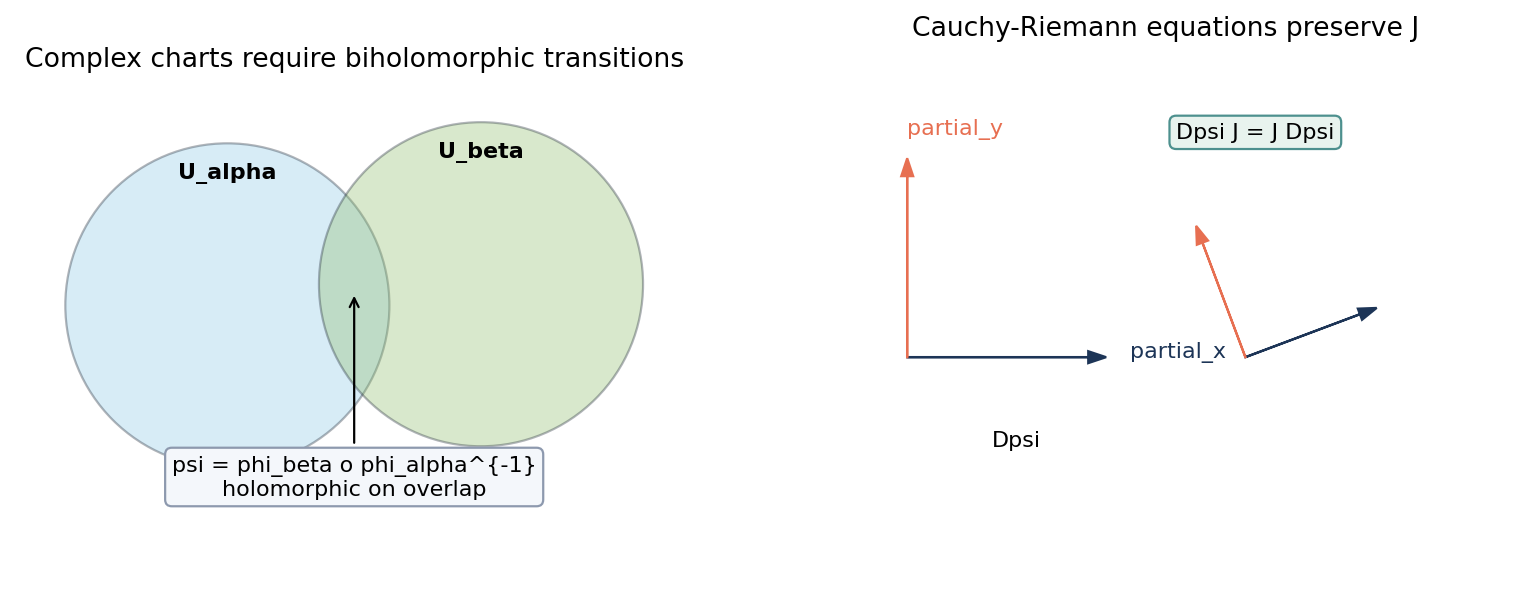

complex type decomposition lattice -> artifacts\lecture-15\figures\complex-type-decomposition-lattice.png


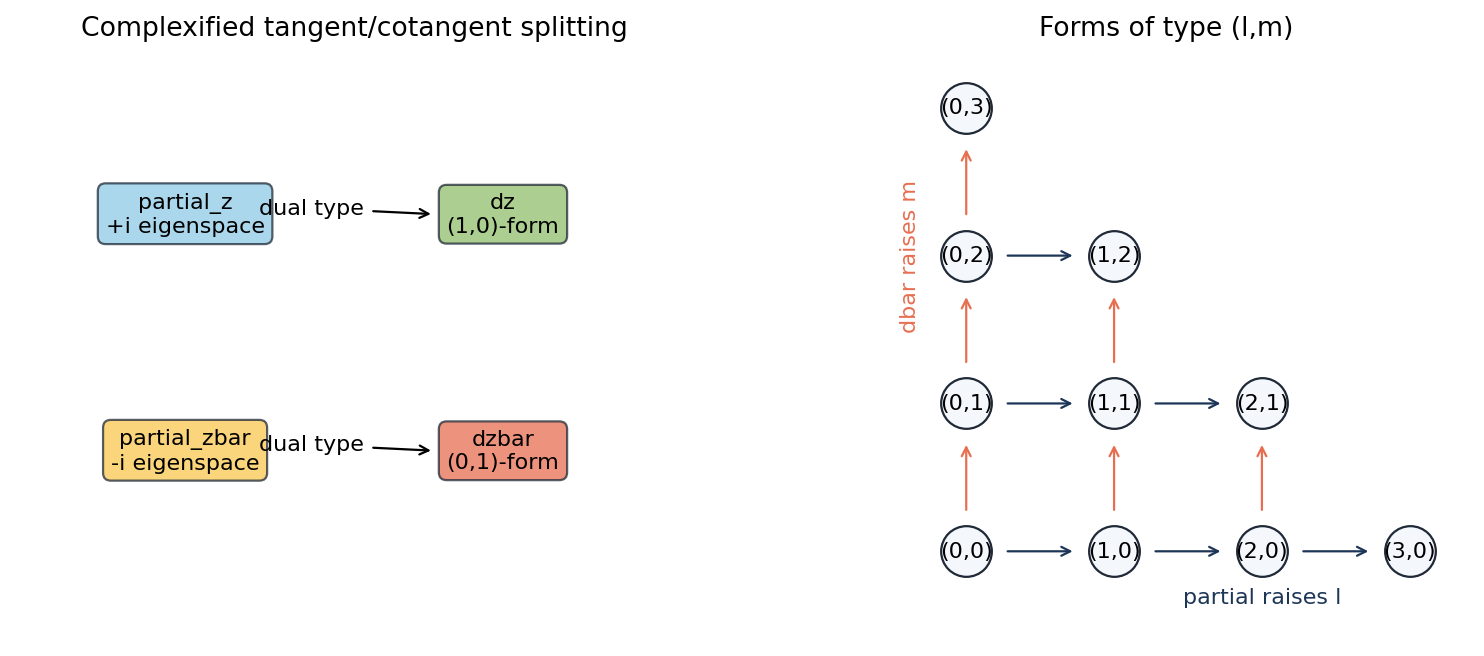

CP1 two-chart atlas -> artifacts\lecture-15\figures\cp1-two-chart-holomorphic-transition.png


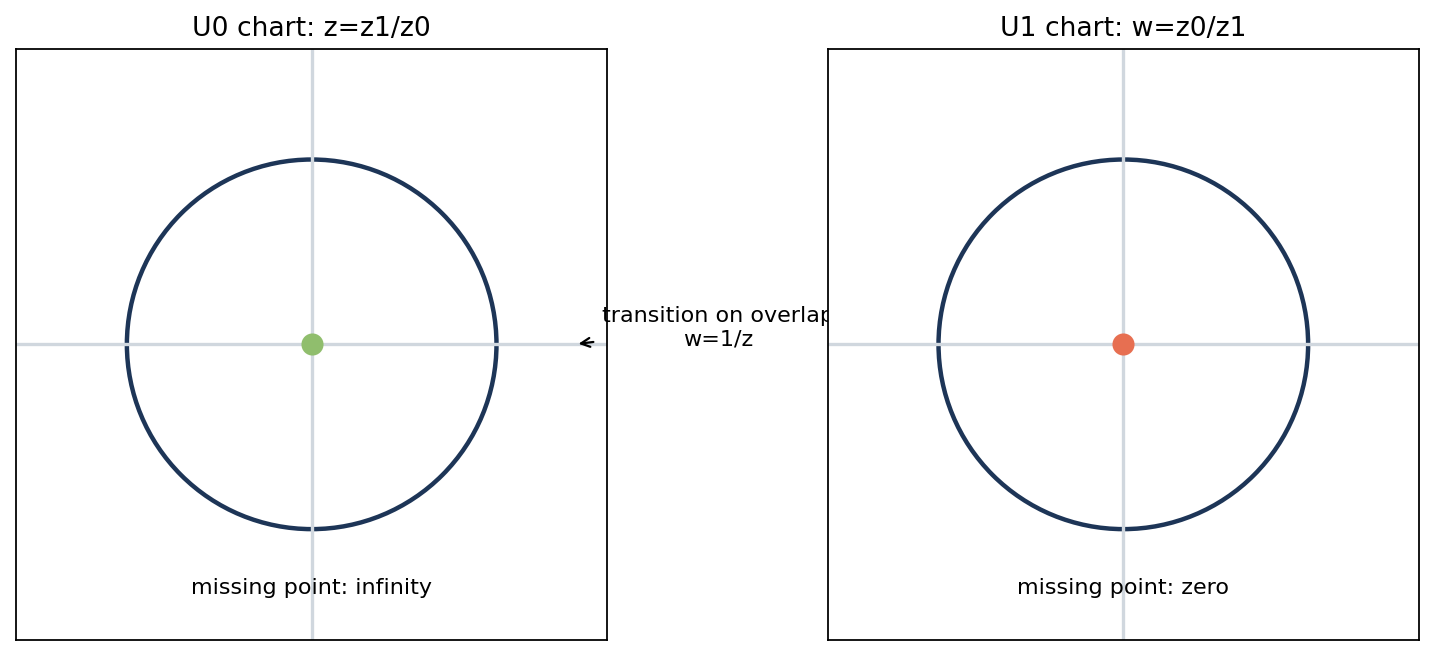

Dolbeault integrability ledger -> artifacts\lecture-15\figures\dolbeault-newlander-nirenberg-ledger.png


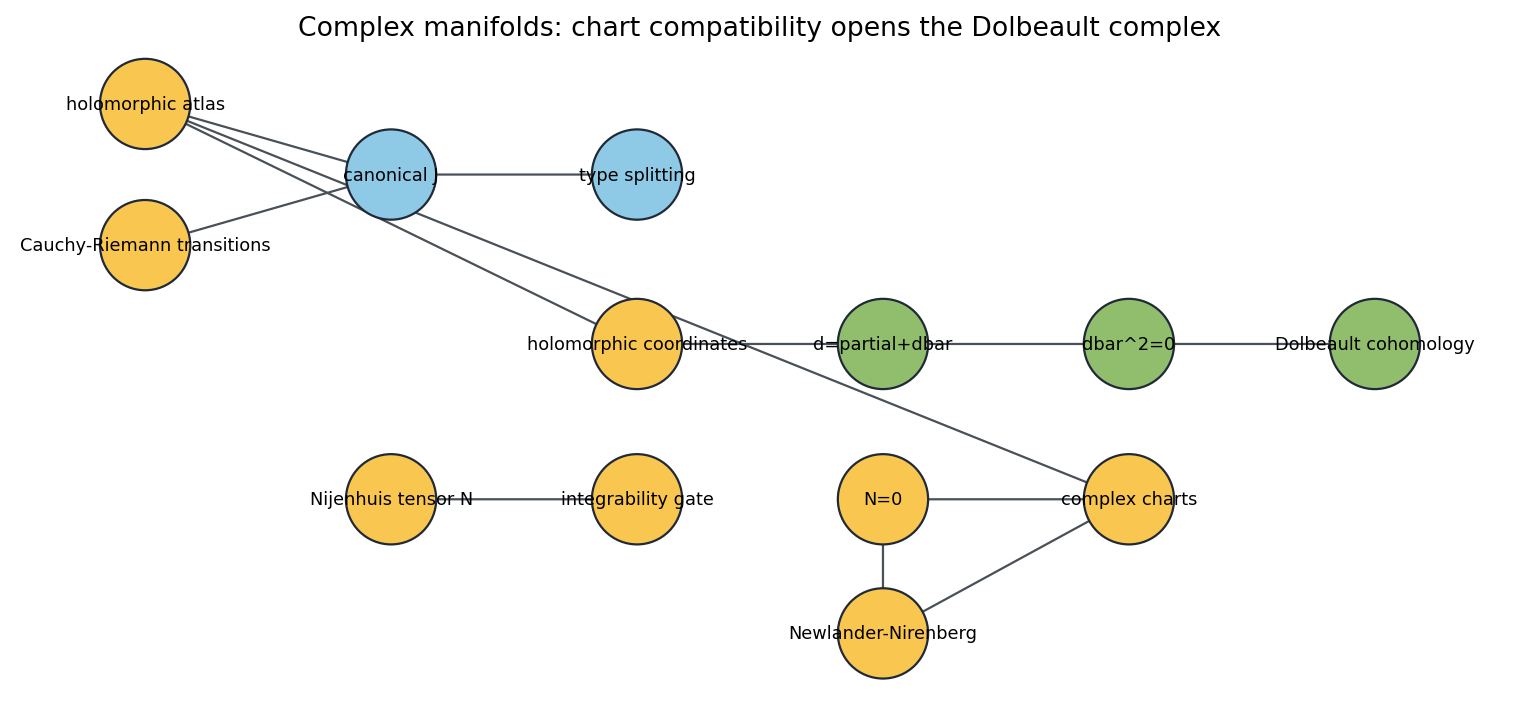

In [8]:
storyboard=read_json(ARTIFACT_ROOT/"checks"/"visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path=BOOK_ROOT/item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path,width=820)

## Takeaways

- Complex manifolds are glued from charts with biholomorphic transition maps.
- Cauchy-Riemann equations make the local almost complex structure `J` chart-independent.
- Holomorphic coordinates split tangent and cotangent spaces into `(1,0)` and `(0,1)` pieces.
- In complex manifolds, `d=partial+dbar` and `dbar^2=0`, producing Dolbeault cohomology.
- Newlander-Nirenberg identifies the missing hypothesis for an almost complex structure to come from complex charts.
- Complex projective space is built from homogeneous-coordinate charts whose transitions are holomorphic on overlaps.

**Exploration prompt.** Replace the CP1 transition `1/z` by `1/zbar` in the symbolic check. The `dbar` residual exposes why antiholomorphic transitions do not define the same complex atlas.